# Teste de hipoteses na pratica

Este notebook acompanha a Secao 1 das notas mostrando, em codigo, como a logica do teste de hipoteses aparece no exemplo da maquina de garrafas.

Fluxo do notebook:
1. carregar os dados e resumir a amostra;
2. calcular a estatistica de teste e o p-valor;
3. visualizar quao incomum seria a media observada se $H_0$ fosse verdadeira;
4. simular repeticoes para conectar $\alpha$ ao erro tipo I.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

amostra = np.array([
    484.11, 459.49, 471.38, 512.01, 494.48,
    528.63, 493.64, 485.03, 473.88, 501.59,
    502.85, 538.08, 465.68, 495.03, 475.32,
    464.32, 449.08, 489.27, 518.13, 529.41,
])

mu0 = 500
alpha = 0.05
rng = np.random.default_rng(1625)

## 1. Resumo da amostra

As notas discutem por que uma media amostral abaixo de 500 ml nao basta, sozinha, para concluir que a maquina esta desregulada. O primeiro passo e medir o tamanho desse desvio em relacao a variabilidade observada.

In [2]:
n = amostra.size
media = amostra.mean()
desvio = amostra.std(ddof=1)
erro_padrao = desvio / np.sqrt(n)

print(f"n = {n}")
print(f"media amostral = {media:.2f} ml")
print(f"desvio-padrao amostral = {desvio:.2f} ml")
print(f"erro-padrao da media = {erro_padrao:.2f} ml")
print(f"desvio em relacao a 500 ml = {media - mu0:.2f} ml")

n = 20
media amostral = 491.57 ml
desvio-padrao amostral = 24.79 ml
erro-padrao da media = 5.54 ml
desvio em relacao a 500 ml = -8.43 ml


## 2. Estatistica de teste e p-valor

Como a variancia populacional e desconhecida e a amostra e pequena, usamos a estatistica $t$ para testar:

- $H_0: \mu \ge 500$
- $H_a: \mu < 500$

O calculo abaixo implementa exatamente as etapas da Secao 1: estatistica observada, p-valor e decisao para um valor de $\alpha$.

In [3]:
gl = n - 1
t_obs = (media - mu0) / erro_padrao
p_valor = stats.t.cdf(t_obs, df=gl)

print(f"t observado = {t_obs:.3f}")
print(f"graus de liberdade = {gl}")
print(f"p-valor unilateral a esquerda = {p_valor:.4f}")
print(f"decisao para alpha = {alpha:.2f}: {'rejeitar H0' if p_valor <= alpha else 'nao rejeitar H0'}")

t observado = -1.520
graus de liberdade = 19
p-valor unilateral a esquerda = 0.0724
decisao para alpha = 0.05: nao rejeitar H0


In [4]:
alphas = np.array([0.10, 0.05, 0.01])
for nivel in alphas:
    decisao = 'rejeitar H0' if p_valor <= nivel else 'nao rejeitar H0'
    print(f"alpha = {nivel:>4.2f} -> {decisao}")

alpha = 0.10 -> rejeitar H0
alpha = 0.05 -> nao rejeitar H0
alpha = 0.01 -> nao rejeitar H0


## 3. O que significa esse p-valor nos dados?

Uma forma de enxergar o p-valor e simular o comportamento da media amostral quando $H_0$ e verdadeira. Para isso, geramos muitas amostras com media 500 ml e desvio-padrao igual ao observado na amostra real.

Isso nao substitui o teste formal, mas ajuda a visualizar a ideia de "resultado raro sob $H_0$".

proporcao simulada de medias <= 491.57 ml: 0.0647


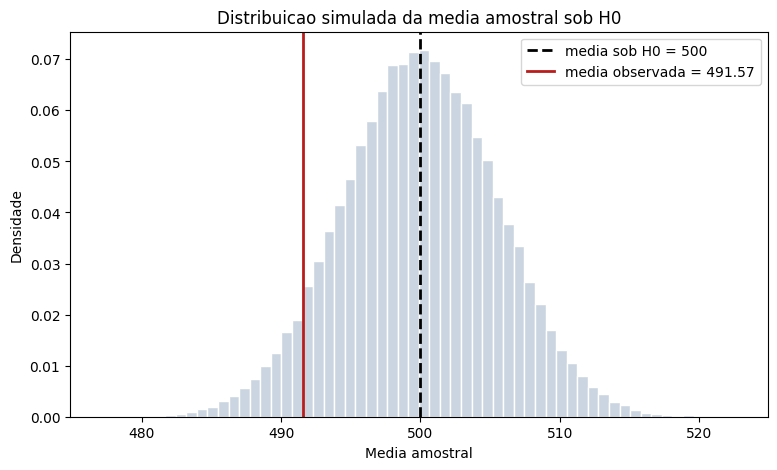

In [5]:
n_sim = 100_000
medias_h0 = rng.normal(loc=mu0, scale=desvio, size=(n_sim, n)).mean(axis=1)
p_simulado = np.mean(medias_h0 <= media)

print(f"proporcao simulada de medias <= {media:.2f} ml: {p_simulado:.4f}")

plt.figure(figsize=(9, 5))
plt.hist(medias_h0, bins=60, density=True, color='#cbd5e1', edgecolor='white')
plt.axvline(mu0, color='black', linestyle='--', linewidth=2, label='media sob H0 = 500')
plt.axvline(media, color='#b91c1c', linewidth=2, label=f'media observada = {media:.2f}')
plt.title('Distribuicao simulada da media amostral sob H0')
plt.xlabel('Media amostral')
plt.ylabel('Densidade')
plt.legend()
plt.show()

## 4. Ligando $\alpha$ ao erro tipo I

As notas definem erro tipo I como rejeitar $H_0$ quando ela e verdadeira. A simulacao abaixo repete o teste muitas vezes em um cenario onde $H_0$ realmente vale e mede com que frequencia a regra de decisao rejeita por acaso.

In [6]:
n_rep = 50_000
amostras_h0 = rng.normal(loc=mu0, scale=desvio, size=(n_rep, n))
medias_rep = amostras_h0.mean(axis=1)
desvios_rep = amostras_h0.std(axis=1, ddof=1)
erros_rep = desvios_rep / np.sqrt(n)
t_rep = (medias_rep - mu0) / erros_rep
p_rep = stats.t.cdf(t_rep, df=gl)

for nivel in [0.10, 0.05, 0.01]:
    taxa = np.mean(p_rep <= nivel)
    print(f"alpha = {nivel:>4.2f} -> taxa simulada de erro tipo I = {taxa:.4f}")

alpha = 0.10 -> taxa simulada de erro tipo I = 0.0988
alpha = 0.05 -> taxa simulada de erro tipo I = 0.0501
alpha = 0.01 -> taxa simulada de erro tipo I = 0.0093


## 5. Fechamento

Use este notebook junto com as notas para responder, em codigo, as perguntas centrais da Secao 1:

- quao longe a amostra caiu do valor de referencia;
- quao raro esse resultado seria sob $H_0$;
- se o p-valor fica abaixo do nivel de significancia escolhido;
- como a escolha de $\alpha$ controla a frequencia de falsos positivos ao longo de repeticoes.